# Trabajo SVM
Javier Amores Gálvez

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import seaborn as sns; sns.set()

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
from sklearn.utils import shuffle
from sklearn.preprocessing import LabelEncoder

from sklearn import svm, datasets
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn import decomposition as de


import pandas as pd
import warnings



In [2]:
pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_original = fetch_ucirepo(id=15)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_original.data.features
Y = breast_cancer_wisconsin_original.data.targets

# metadata
print(breast_cancer_wisconsin_original.metadata)

# variable information
print(breast_cancer_wisconsin_original.variables)

{'uci_id': 15, 'name': 'Breast Cancer Wisconsin (Original)', 'repository_url': 'https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original', 'data_url': 'https://archive.ics.uci.edu/static/public/15/data.csv', 'abstract': 'Original Wisconsin Breast Cancer Database', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 699, 'num_features': 9, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['Class'], 'index_col': ['Sample_code_number'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1990, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C5HP4Z', 'creators': ['WIlliam Wolberg'], 'intro_paper': None, 'additional_info': {'summary': "Samples arrive periodically as Dr. Wolberg reports his clinical cases. The database therefore reflects this chronological grouping of the data. This grouping information appears immediately below, having been removed fro

La base de datos elegida consiste en 699 casos de posibles cánceres de mama, recogidos entre enero de 1989 y noviembre de 1991. El repositorio puede encontrarse en https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original.

Construir reglas de clasificación para una base de datos que determine si un tumor es benigno o maligno es crucial para mejorar el diagnóstico temprano y preciso, reducir errores humanos, y optimizar recursos médicos. Esto no solo apoya a los médicos en la toma de decisiones consistentes y fundamentadas, sino que también tranquiliza a los pacientes al proporcionar información clara sobre su condición. Además, estas reglas ayudan a evitar tratamientos innecesarios, cumplen con los estándares médicos, y facilitan la mejora continua en las técnicas de diagnóstico y tratamiento, contribuyendo así a una atención de salud más eficiente y eficaz.

La variable respuesta (llamada **Class** en la base de datos) es de tipo binaria, y consiste en determinar si un tumor es benigno (denotado con un 2) o maligno (denotado con un 4).

Contamos además con 9 variables explicativas de tipo numérico,cuyos valores son enteros. Se describen a continuación:




1.   **Clump_thickness**. Mide el grosor de los grupos de células.
2. **Uniformity_of_cell_size**. Evalúa la uniformidad del tamaño de las células.
3. **Uniformity_of_cell_shape**. Evalúa la uniformidad de la forma de las células.
4. **Marginal_adhesion**. Mide la adhesión marginal de las células.
5. **Single_epithelial_cell_size**. Mide el tamaño de las células epiteliales.
6. **Bare_nuclei**. Sus valores son enteros que representan la cantidad de núcleos sin citoplasma circundante. Destacar que esta variable contiene datos faltantes.
7. **Bland_chromatin**. Evalúa la cromatina (material genético) en la célula.
8. **Normal_nucleoli**. Mide la cantidad de nucléolos normales.
9. **Mitoses**. Sus valores son enteros que representan la frecuencia de mitosis.


In [4]:
X

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
0,5,1,1,1,2,1.0,3,1,1
1,5,4,4,5,7,10.0,3,2,1
2,3,1,1,1,2,2.0,3,1,1
3,6,8,8,1,3,4.0,3,7,1
4,4,1,1,3,2,1.0,3,1,1
...,...,...,...,...,...,...,...,...,...
694,3,1,1,1,3,2.0,1,1,1
695,2,1,1,1,2,1.0,1,1,1
696,5,10,10,3,7,3.0,8,10,2
697,4,8,6,4,3,4.0,10,6,1


In [5]:
Y

,Class
0,2
1,2
2,2
3,2
4,2
...,...
694,2
695,2
696,4
697,4


A continuación se muestra un resumen de las medidas estadísticas de cada variable explicativa

In [6]:
X.describe()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
count,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413
std,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


Como todas las variables se mueven entre los mismos valores (entre $1$ y $10$), no parece necesario normalizar los datos.

In [7]:
n_benign = Y[Y['Class']==2].count()[0]
n_malignant = Y[Y['Class']==4].count()[0]
print('El número de tumores benignos en la base de datos es {} ({} %)'.format(n_benign,100*n_benign/699))
print('El número de tumores malignos en la base de datos es {} ({} %)'.format(n_malignant,100*n_malignant/699))

El número de tumores benignos en la base de datos es 458 (65.52217453505007 %)
El número de tumores malignos en la base de datos es 241 (34.47782546494993 %)


Veamos si existe correlación lineal entre alguna de las variables.

                             Clump_thickness  Uniformity_of_cell_size  \
Clump_thickness                     1.000000                 0.644913   
Uniformity_of_cell_size             0.644913                 1.000000   
Uniformity_of_cell_shape            0.654589                 0.906882   
Marginal_adhesion                   0.486356                 0.705582   
Single_epithelial_cell_size         0.521816                 0.751799   
Bare_nuclei                         0.593091                 0.691709   
Bland_chromatin                     0.558428                 0.755721   
Normal_nucleoli                     0.535835                 0.722865   
Mitoses                             0.350034                 0.458693   

                             Uniformity_of_cell_shape  Marginal_adhesion  \
Clump_thickness                              0.654589           0.486356   
Uniformity_of_cell_size                      0.906882           0.705582   
Uniformity_of_cell_shape                 

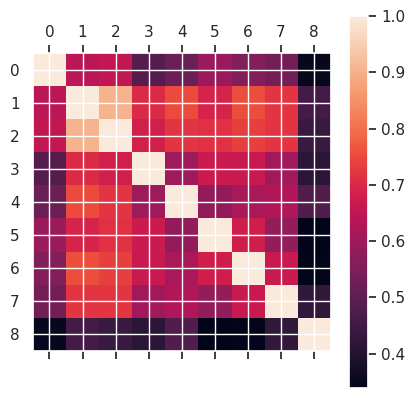

In [8]:
correlations = X.corr()
print(correlations)
plt.matshow(correlations)
plt.colorbar()
plt.show()

**Uniformity_of_cell_size** y **Uniformity_of_cell_shape** están fuertemente correlacionadas.  En general, la matriz de correlaciones indica que ciertas características celulares, especialmente aquellas relacionadas con la uniformidad, están correlacionadas entre sí.

Antes de empezar, con el proceso de validación cruzada, tenemos que hacer algo respecto a los datos faltantes de la variable **Bare_nuclei**. Lo más sencillo (sin meternos en técnicas avanzadas del tratamiento de falta de información), es o bien trabajar si esta variable, o bien trabajar sin las observaciones que no tengan un valor es esa variable. Lo haremos de las dos formas y posteriormente compararemos los resultados.

In [9]:
X_new = X.drop(columns=['Bare_nuclei'])

In [10]:
X_new

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bland_chromatin,Normal_nucleoli,Mitoses
0,5,1,1,1,2,3,1,1
1,5,4,4,5,7,3,2,1
2,3,1,1,1,2,3,1,1
3,6,8,8,1,3,3,7,1
4,4,1,1,3,2,3,1,1
...,...,...,...,...,...,...,...,...
694,3,1,1,1,3,1,1,1
695,2,1,1,1,2,1,1,1
696,5,10,10,3,7,8,10,2
697,4,8,6,4,3,10,6,1


In [11]:
Xtrain1, Xtest1, Ytrain1, Ytest1 = train_test_split(X_new, Y, random_state = 0)

Realizamos la validación cruzada con $3$ tipos de kernel: Lineal, polinómico y gaussiano. Los parametros que se han usado están en la lista **parametros**.

In [12]:
parametros =[ {
        'kernel': ['rbf'],
        'gamma' : [1e-4,1e-3,0.02, 0.1, 0.2, 0.5],
        'C': [1,10,100,1000]
    },     {
        'kernel':["linear"],
        'C':[1,10,100,1000]
   },{
       'kernel':["poly"],
       'degree':[2,3],
       'C': [1,10,100,1000]
   }]

warnings.filterwarnings('ignore')

model = GridSearchCV(svm.SVC(decision_function_shape='ovr'), param_grid=parametros, cv=5)
model.fit(Xtrain1, Ytrain1)
model.best_params_
model.score(Xtest1,Ytest1)


0.96

In [13]:
model.best_params_

{'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}

El mejor modelo encontrado corresponde al del kernel gaussiano con $\gamma = 0.001$ y $C = 100$.

Predecimos la variable objetivo del conjunto test con este modelo.

In [14]:
classifier = model.best_estimator_
Y_fit1 = classifier.predict(Xtest1)

Vectores soporte

In [15]:
SV = classifier.support_vectors_
print("El número de vectores soporte es {}".format(len(SV)))

El número de vectores soporte es 52


In [16]:
SV

array([[ 4.,  6.,  5.,  6.,  7.,  4.,  9.,  1.],
       [ 8.,  4.,  4.,  5.,  4.,  7.,  8.,  2.],
       [ 6.,  3.,  3.,  5.,  3.,  3.,  5.,  3.],
       [ 7.,  1.,  2.,  3.,  2.,  2.,  1.,  1.],
       [ 4.,  4.,  4.,  4.,  6.,  7.,  3.,  1.],
       [ 6.,  9.,  7.,  5.,  5.,  4.,  2.,  1.],
       [ 3.,  3.,  2.,  6.,  3.,  3.,  5.,  1.],
       [ 6.,  8.,  8.,  1.,  3.,  3.,  7.,  1.],
       [ 8.,  2.,  1.,  1.,  5.,  1.,  1.,  1.],
       [ 5.,  7.,  7.,  1.,  5.,  3.,  4.,  1.],
       [ 6.,  1.,  3.,  1.,  2.,  3.,  1.,  1.],
       [ 6.,  3.,  3.,  3.,  3.,  6.,  1.,  1.],
       [ 5.,  3.,  4.,  1.,  4.,  3.,  1.,  1.],
       [ 8.,  3.,  3.,  1.,  2.,  3.,  2.,  1.],
       [ 8.,  4.,  6.,  3.,  3.,  4.,  3.,  1.],
       [ 5.,  4.,  3.,  1.,  2.,  2.,  3.,  1.],
       [ 5.,  3.,  4.,  3.,  4.,  4.,  7.,  1.],
       [ 5.,  1.,  1.,  6.,  3.,  2.,  1.,  1.],
       [ 5.,  4.,  5.,  1.,  8.,  3.,  6.,  1.],
       [ 3.,  1.,  1.,  3.,  8.,  5.,  8.,  1.],
       [ 4.,  3.,  1

Matriz de confusión.

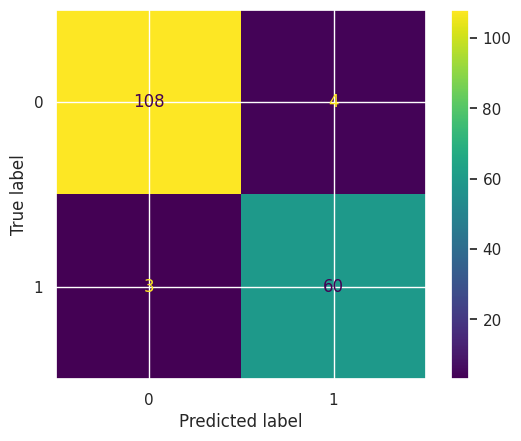

In [17]:
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(Ytest1,Y_fit1))

cm_display.plot()
plt.show()

In [18]:
CM = confusion_matrix(Ytest1, Y_fit1)

#TP = True positive; FP = False positive; FN = False negative; TN = True negative
TP= CM[0,0]
FP= CM[1,0]
FN = CM[0,1]
TN= CM[1,1]

sen = TP/(TP+FP)
spe = TN/(TN+FN)
print("Sensitivity: ", sen)
print("Specificity: ", spe)
print("Accuracy: ", (TN+TP)/(TN+FN+TP+FP))
print("AUC", (sen+spe)/2)

Sensitivity:  0.972972972972973
Specificity:  0.9375
Accuracy:  0.96
AUC 0.9552364864864865


La precisión es de $0.96$ y el área bajo la curva Roc es aproximadamente $0.9552$, por lo que parece que el modelo es bueno.

Ahora hacemos lo mismo eliminando las observaciones con datos faltantes.

In [19]:
Aux = X.join(Y)
XY = Aux.dropna()
XY

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...
694,3,1,1,1,3,2.0,1,1,1,2
695,2,1,1,1,2,1.0,1,1,1,2
696,5,10,10,3,7,3.0,8,10,2,4
697,4,8,6,4,3,4.0,10,6,1,4


In [20]:
X_new2 = XY.iloc[:,:9]
Y_new2 = XY['Class']
X_new2

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
0,5,1,1,1,2,1.0,3,1,1
1,5,4,4,5,7,10.0,3,2,1
2,3,1,1,1,2,2.0,3,1,1
3,6,8,8,1,3,4.0,3,7,1
4,4,1,1,3,2,1.0,3,1,1
...,...,...,...,...,...,...,...,...,...
694,3,1,1,1,3,2.0,1,1,1
695,2,1,1,1,2,1.0,1,1,1
696,5,10,10,3,7,3.0,8,10,2
697,4,8,6,4,3,4.0,10,6,1


Ahora tan solo tenemos $683$ observaciones.

In [21]:
Xtrain2, Xtest2, Ytrain2, Ytest2 = train_test_split(X_new2, Y_new2, random_state = 0)

In [22]:
parametros =[ {
        'kernel': ['rbf'],
        'gamma' : [1e-4,1e-3,0.02, 0.1, 0.2, 0.5],
        'C': [1,10,100,1000]
    },     {
        'kernel':["linear"],
        'C':[1,10,100,1000]
   },{
       'kernel':["poly"],
       'degree':[2,3],
       'C': [1,10,100,1000]
   }]



model2 = GridSearchCV(svm.SVC(decision_function_shape='ovr'), param_grid=parametros, cv=5)
model2.fit(Xtrain2, Ytrain2)
model2.best_params_
model2.score(Xtest2,Ytest2)

0.935672514619883

Parece que también hemos obtenido un buen modelo, aunque ya podemos ver que la precisión es un poco menor que antes.

In [23]:
model2.best_params_

{'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}

Ahora el mejor modelo encontrado corresponde al del kernel gaussiano con $\gamma = 0.001$ y $C = 1$. Es decir, ahora no penalizamos tanto el error.

In [24]:
classifier2 = model2.best_estimator_
Y_fit2 = classifier2.predict(Xtest2)

In [25]:
SV2 = classifier2.support_vectors_
print("El número de vectores soporte es {}".format(len(SV2)))

El número de vectores soporte es 70


In [26]:
SV2

array([[ 5.,  1.,  3.,  3.,  2.,  2.,  2.,  3.,  1.],
       [ 1.,  1.,  1.,  1.,  2., 10.,  3.,  1.,  1.],
       [ 8.,  4.,  4.,  5.,  4.,  7.,  7.,  8.,  2.],
       [ 4.,  4.,  4.,  4.,  6.,  5.,  7.,  3.,  1.],
       [ 5.,  2.,  2.,  4.,  2.,  4.,  1.,  1.,  1.],
       [ 5.,  1.,  2., 10.,  4.,  5.,  2.,  1.,  1.],
       [ 1.,  3.,  1.,  2.,  2.,  2.,  5.,  3.,  2.],
       [ 6.,  8.,  8.,  1.,  3.,  4.,  3.,  7.,  1.],
       [ 3.,  3.,  2.,  1.,  2.,  3.,  3.,  1.,  1.],
       [ 5.,  1.,  1.,  3.,  4.,  1.,  3.,  2.,  1.],
       [ 4.,  4.,  2.,  1.,  2.,  5.,  2.,  1.,  2.],
       [ 3.,  3.,  2.,  6.,  3.,  3.,  3.,  5.,  1.],
       [ 4.,  2.,  4.,  3.,  2.,  2.,  2.,  1.,  1.],
       [ 6.,  9.,  7.,  5.,  5.,  8.,  4.,  2.,  1.],
       [ 3.,  2.,  2.,  3.,  2.,  3.,  3.,  1.,  1.],
       [ 3.,  2.,  2.,  1.,  4.,  3.,  2.,  1.,  1.],
       [ 4.,  1.,  1.,  1.,  2.,  1.,  3.,  6.,  1.],
       [ 8.,  3.,  3.,  1.,  2.,  2.,  3.,  2.,  1.],
       [ 6.,  3.,  3.,  3., 

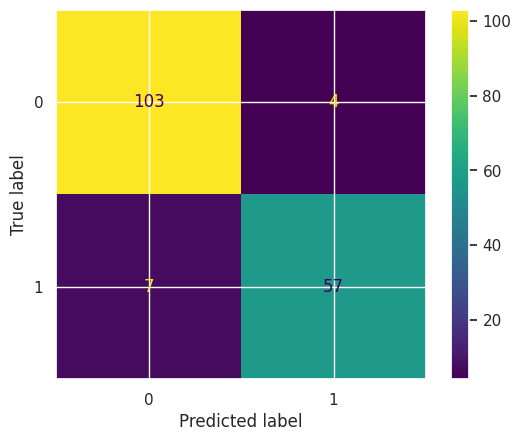

In [27]:
cm_display2 = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(Ytest2,Y_fit2))

cm_display2.plot()
plt.show()

In [28]:
CM2 = confusion_matrix(Ytest2, Y_fit2)

#TP = True positive; FP = False positive; FN = False negative; TN = True negative
TP2= CM2[0,0]
FP2= CM2[1,0]
FN2 = CM2[0,1]
TN2= CM2[1,1]

sen2 = TP2/(TP2+FP2)
spe2 = TN2/(TN2+FN2)
print("Sensitivity: ", sen2)
print("Specificity: ", spe2)
print("Accuracy: ", (TN2+TP2)/(TN2+FN2+TP2+FP2))
print("AUC", (sen2+spe2)/2)

Sensitivity:  0.9363636363636364
Specificity:  0.9344262295081968
Accuracy:  0.935672514619883
AUC 0.9353949329359166


Este modelo también es válido, aunque da resultados ligeramente peores que el anterior.

Para terminar, vamos a intentar un método que nos permita visualizar un hiperplano. Consiste en realizar prevaimente el análisis de componentes principales (PCA) y quedarnos con las primeras componentes principales para ajustar el modelo.

In [29]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale

In [30]:
# Entrenamiento modelo PCA
pca_pipe = make_pipeline(StandardScaler(), PCA())
pca_pipe.fit(X_new)

# Se extrae el modelo entrenado del pipeline
modelo_pca = pca_pipe.named_steps['pca']

In [31]:
pd.DataFrame(
    data    = modelo_pca.components_,
    columns = X_new.columns,
    index   = ['PC1', 'PC2', 'PC3', 'PC4','PC5','PC6','PC7','PC8']
)

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bland_chromatin,Normal_nucleoli,Mitoses
PC1,0.318596,0.405130,0.399405,0.348916,0.359319,0.363963,0.359195,0.249999
PC2,-0.168231,-0.103362,-0.129947,-0.039554,0.115296,-0.264294,-0.043341,0.926035
PC3,-0.862402,0.017994,-0.035524,0.422560,0.108970,0.196867,0.129836,-0.092902
PC4,0.236803,-0.131212,-0.130121,0.655871,-0.584732,0.195801,-0.275068,0.153940
PC5,0.038930,0.131551,0.083978,0.245748,0.518529,-0.181008,-0.774815,-0.108446
PC6,-0.149956,0.109332,0.088937,-0.449809,-0.124396,0.736834,-0.403295,0.185137
PC7,0.214733,-0.469657,-0.596308,0.068297,0.463833,0.378277,0.115516,-0.038553
PC8,0.016406,0.746866,-0.659432,-0.024185,-0.065753,-0.042456,0.015859,-0.010413


In [32]:
print('Porcentaje de varianza explicada por cada componente')
print('----------------------------------------------------')
print(modelo_pca.explained_variance_ratio_)

Porcentaje de varianza explicada por cada componente
----------------------------------------------------
[0.65982301 0.09339484 0.06735342 0.05104741 0.04695641 0.03728969
 0.03283384 0.01130138]


In [33]:
0.65982301 +0.09339484

0.75321785

Las dos primeras componentes principales explican el 75.32% de la varianza.

In [34]:
proyecciones = pca_pipe.transform(X=X_new)
proyecciones = pd.DataFrame(
    proyecciones,
    columns = ['PC1', 'PC2', 'PC3', 'PC4','PC5','PC6','PC7','PC8'],
    index   = X_new.index
)

Observaciones en términos de componentes principales.

In [35]:
proyecciones

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,-1.304088,-0.148659,-0.574980,0.223761,-0.043164,0.230227,0.392896,0.023704
1,0.916752,-0.190742,0.287998,-0.528774,1.433383,-0.616196,0.510162,-0.084927
2,-1.530546,-0.029081,0.038016,0.055441,-0.070835,0.336816,0.240264,0.012042
3,1.549261,-0.785137,-0.619362,-1.105117,-0.818558,-0.211659,-1.577728,0.191199
4,-1.172750,-0.116595,0.027705,0.599323,0.115253,-0.031765,0.364452,0.000921
...,...,...,...,...,...,...,...,...
694,-1.666902,0.239961,-0.074326,-0.369534,0.312078,-0.324203,0.139392,0.017175
695,-1.942520,0.247644,0.182924,-0.189434,0.063902,-0.214690,-0.146546,0.041060
696,4.110722,-0.744578,0.645608,-1.739107,-0.776402,0.656609,-0.610007,0.017719
697,2.348565,-1.364702,0.984856,0.156423,-0.910494,1.611072,-0.208098,0.471038


Para el SVM usaremos las dos primeras componentes principales.

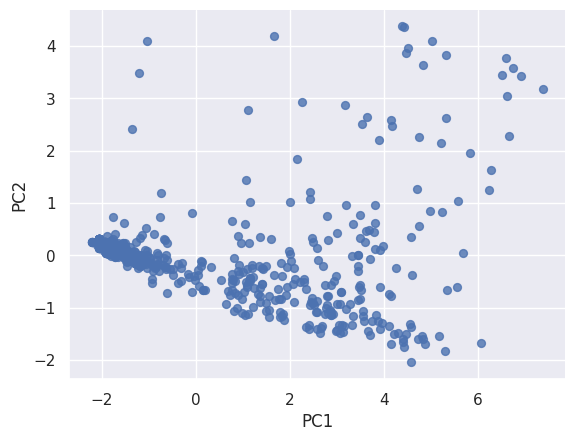

In [36]:
proyecciones.plot(kind='scatter', x='PC1', y='PC2', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

In [37]:
color = Y["Class"]

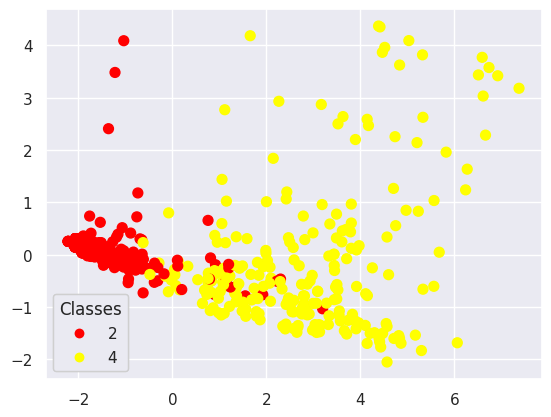

In [38]:
fig, ax = plt.subplots()
scatter = ax.scatter(proyecciones.iloc[:,0], proyecciones.iloc[:,1], c = color, s = 50, cmap="autumn")
legend = ax.legend(*scatter.legend_elements(),
                    loc="lower left", title="Classes")
ax.add_artist(legend)
plt.show()

In [39]:
proyecciones.iloc[:,:2]

,PC1,PC2
0,-1.304088,-0.148659
1,0.916752,-0.190742
2,-1.530546,-0.029081
3,1.549261,-0.785137
4,-1.172750,-0.116595
...,...,...
694,-1.666902,0.239961
695,-1.942520,0.247644
696,4.110722,-0.744578
697,2.348565,-1.364702


In [40]:
Xtrain3, Xtest3, Ytrain3, Ytest3 = train_test_split(proyecciones.iloc[:,:2], Y, random_state = 0)

In [41]:
parametros =[ {
        'kernel': ['rbf'],
        'gamma' : [1e-4,1e-3,0.02, 0.1, 0.2, 0.5],
        'C': [1,10,100,1000]
    },     {
        'kernel':["linear"],
        'C':[1,10,100,1000]
   },{
       'kernel':["poly"],
       'degree':[2,3],
       'C': [1,10,100,1000]
   }]



model3 = GridSearchCV(svm.SVC(decision_function_shape='ovr'), param_grid=parametros, cv=5)
model3.fit(Xtrain3, Ytrain3)
model3.best_params_
model3.score(Xtest3,Ytest3)

0.96

In [42]:
model3.best_params_

{'C': 10, 'gamma': 0.2, 'kernel': 'rbf'}

El mejor modelo encontrado sigue siendo uno con kernel gaussiano. Sin embargo ahora los parámetros son $\gamma = 0.2$ y $C = 10$.

In [43]:
classifier3 = model3.best_estimator_
Y_fit3 = classifier3.predict(Xtest3)

In [44]:
SV3 = classifier3.support_vectors_
print("El número de vectores soporte es {}".format(len(SV3)))

El número de vectores soporte es 52


In [45]:
SV3

array([[ 2.29938019, -0.46425649],
       [ 2.21891054, -0.50519419],
       [ 0.75795599,  0.65673634],
       [-0.73495438,  1.18099267],
       [ 1.23405246, -0.6172702 ],
       [ 1.92235002, -0.76396639],
       [ 0.11432234, -0.21465019],
       [ 1.54926083, -0.7851369 ],
       [ 1.14031908, -0.5008721 ],
       [-1.22063421,  3.48341034],
       [ 0.19891404, -0.66477713],
       [-0.3101204 , -0.24351056],
       [-0.31198606, -0.49753776],
       [ 0.89838368, -0.76099329],
       [-0.55047199, -0.25780263],
       [-0.37938171, -0.15954172],
       [ 0.790096  , -0.46492244],
       [ 1.19534808, -0.18375617],
       [ 0.81108547, -0.06052702],
       [-0.17823245, -0.36455498],
       [-0.4847149 , -0.26572271],
       [-0.38481881, -0.5267449 ],
       [ 0.53911963, -0.47647913],
       [-0.02230901, -0.48276849],
       [-0.07983264,  0.80038162],
       [ 6.23616892,  1.23991237],
       [ 0.12473355, -0.12326687],
       [ 1.73854623, -0.64026713],
       [ 6.05966199,

Pasamos a dibujar el hiperplano

(-5.0, 6.0)

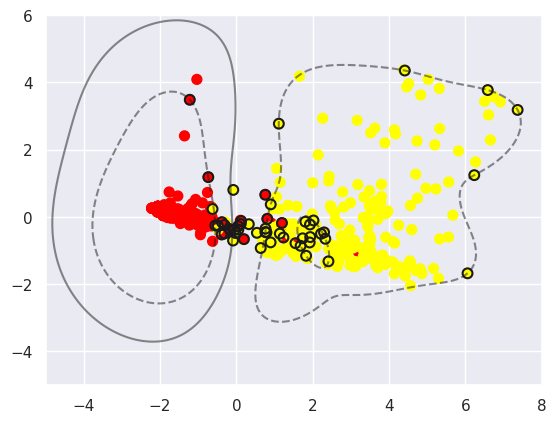

In [46]:
plt.scatter(proyecciones.iloc[:,0], proyecciones.iloc[:,1], c=color, s=50, cmap="autumn")

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()


##Generamos la parrila de puntos para evaluar el modelo
xx = np.linspace(-5, 10, 300)
yy = np.linspace(-5, 10, 300)
Y_2, X_2 = np.meshgrid(yy,xx)

xy = np.vstack([X_2.ravel(), Y_2.ravel()]).T
P = classifier3.decision_function(xy).reshape(X_2.shape)

##Representamos las fronteras y los márgenes del SVC
ax.contour(X_2,Y_2,P, colors="k", levels=[-1,0,1], alpha = 0.5, linestyles=["--", "-", "--"])

ax.scatter(SV3[:,0], SV3[:,1], s=50, linewidth=1.5, facecolors = 'none', edgecolor='k')


ax.set_xlim((-5, 8))
ax.set_ylim((-5,6))

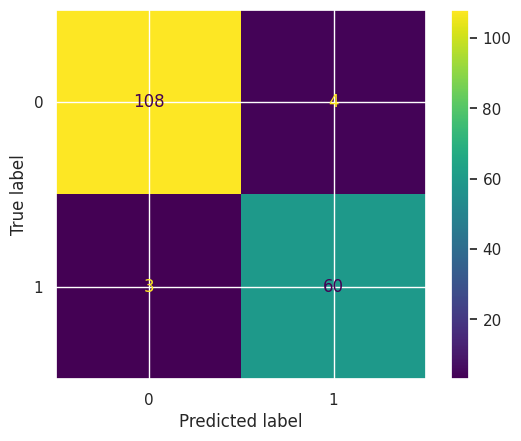

In [47]:
cm_display3 = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(Ytest3,Y_fit3))

cm_display3.plot()
plt.show()

In [48]:
CM3 = confusion_matrix(Ytest3, Y_fit3)

TP3= CM3[0,0]
FP3= CM3[1,0]
FN3 = CM3[0,1]
TN3= CM3[1,1]

sen3 = TP3/(TP3+FP3)
spe3 = TN3/(TN3+FN3)
print("Sensitivity: ", sen3)
print("Specificity: ", spe3)
print("Accuracy: ", (TN3+TP3)/(TN3+FN3+TP3+FP3))
print("AUC", (sen3+spe3)/2)

Sensitivity:  0.972972972972973
Specificity:  0.9375
Accuracy:  0.96
AUC 0.9552364864864865


En cuanto a bondad de ajuste, tenemos los mismos resultados que en el primer modelo.